In [1]:
import os
import pickle
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
from tqdm import tqdm
from tqdm.dask import TqdmCallback

import matplotlib.pyplot as plt

os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')
from utils.config_dataset import *
from utils.ClassDataset import MergedDataset

import warnings
warnings.filterwarnings("ignore")

RANDOMSEED=2024

save_path = 'processed-merge/'

def load_sample(sample_dict_i):
    pid, t_start, t_end = sample_dict_i
    df = pickle.load(open(os.path.join(save_path, 'merged_data_per_pat', f"{pid}.p"), 'rb'))
    sample = df.loc[(df.index>=t_start) & (df.index<t_end)]
    return sample

In [2]:
pid_valid = pickle.load(open(os.path.join(save_path, 'pid_valid_00.p'), 'rb'))
sample_dict_vaso = pickle.load(open(os.path.join(save_path, 'sample_lookuptable_per_med.p'), 'rb'))
sample_dict_control = pickle.load(open(os.path.join(save_path, 'sample_lookuptable_control_group.p'), 'rb'))

pid_sample_vaso = {med:[sample_dict_vaso[med][i][0] for i in sample_dict_vaso[med]] 
                   for med in sample_dict_vaso }
pid_sample_control = [sample_dict_control[i][0] for i in sample_dict_control]

In [3]:
pid_control, counts = np.unique(pid_sample_control, return_counts=True)
for pid, num in zip(pid_control, counts):
    print(f"{pid:<10} --- {num}")

1          --- 1
3          --- 2
4          --- 13
6          --- 2
7          --- 26
8          --- 2
9          --- 2
13         --- 1
15         --- 5
16         --- 2
17         --- 2
18         --- 1
20         --- 2
21         --- 1
23         --- 2
24         --- 2
25         --- 2
26         --- 1
27         --- 6
28         --- 1
29         --- 1
30         --- 28
31         --- 1
32         --- 1
34         --- 1
35         --- 3
36         --- 5
39         --- 2
40         --- 1
41         --- 2
42         --- 2
44         --- 7
45         --- 2
46         --- 1
47         --- 4
48         --- 3
49         --- 38
50         --- 1
51         --- 5
52         --- 2
53         --- 5
54         --- 1
56         --- 9
57         --- 1
58         --- 2
59         --- 5
60         --- 13
61         --- 6
62         --- 2
63         --- 2
64         --- 2
65         --- 2
66         --- 1
67         --- 14
68         --- 1
69         --- 16
71         --- 1
73         --- 1
74     

2844       --- 2
2845       --- 2
2846       --- 5
2847       --- 3
2848       --- 6
2850       --- 10
2853       --- 6
2854       --- 27
2855       --- 1
2857       --- 2
2859       --- 2
2860       --- 26
2864       --- 6
2865       --- 3
2866       --- 2
2867       --- 3
2868       --- 3
2869       --- 5
2870       --- 1
2873       --- 4
2874       --- 12
2876       --- 2
2877       --- 5
2878       --- 1
2881       --- 4
2882       --- 1
2883       --- 6
2885       --- 2
2887       --- 2
2888       --- 3
2889       --- 2
2891       --- 16
2892       --- 5
2893       --- 2
2894       --- 2
2895       --- 2
2898       --- 1
2899       --- 2
2900       --- 6
2901       --- 2
2902       --- 2
2904       --- 1
2905       --- 2
2906       --- 2
2907       --- 7
2911       --- 2
2912       --- 1
2913       --- 1
2914       --- 5
2916       --- 1
2918       --- 2
2919       --- 2
2920       --- 5
2921       --- 2
2922       --- 2
2923       --- 4
2924       --- 4
2925       --- 2
2926     

8002       --- 2
8003       --- 2
8004       --- 2
8005       --- 3
8006       --- 2
8008       --- 16
8010       --- 1
8011       --- 2
8012       --- 2
8013       --- 2
8014       --- 1
8017       --- 3
8018       --- 2
8019       --- 2
8020       --- 2
8021       --- 1
8022       --- 2
8023       --- 1
8024       --- 1
8025       --- 1
8027       --- 1
8030       --- 4
8031       --- 14
8032       --- 13
8033       --- 5
8034       --- 2
8035       --- 2
8036       --- 2
8037       --- 2
8038       --- 2
8039       --- 7
8041       --- 2
8042       --- 3
8044       --- 9
8046       --- 1
8047       --- 2
8048       --- 3
8049       --- 6
8050       --- 3
8052       --- 2
8053       --- 1
8054       --- 2
8057       --- 21
8058       --- 38
8059       --- 3
8062       --- 1
8063       --- 2
8064       --- 3
8065       --- 2
8066       --- 15
8067       --- 2
8068       --- 1
8069       --- 2
8070       --- 5
8071       --- 2
8072       --- 2
8073       --- 53
8074       --- 8
8075   

12532      --- 2
12534      --- 2
12535      --- 5
12536      --- 1
12537      --- 2
12538      --- 1
12539      --- 1
12540      --- 1
12541      --- 2
12542      --- 2
12543      --- 1
12544      --- 2
12545      --- 2
12546      --- 3
12547      --- 1
12548      --- 1
12549      --- 2
12550      --- 1
12552      --- 4
12553      --- 10
12554      --- 4
12556      --- 2
12557      --- 4
12558      --- 1
12560      --- 1
12561      --- 1
12562      --- 1
12563      --- 1
12565      --- 2
12566      --- 6
12567      --- 2
12568      --- 21
12570      --- 2
12572      --- 29
12573      --- 2
12574      --- 1
12575      --- 1
12576      --- 3
12577      --- 9
12579      --- 7
12580      --- 26
12581      --- 2
12582      --- 1
12584      --- 11
12585      --- 1
12586      --- 1
12587      --- 2
12588      --- 24
12589      --- 2
12590      --- 10
12593      --- 3
12602      --- 2
12603      --- 2
12604      --- 6
12605      --- 2
12606      --- 2
12607      --- 6
12608      --- 5
12609  

16619      --- 1
16620      --- 28
16621      --- 2
16623      --- 2
16624      --- 2
16625      --- 2
16627      --- 2
16629      --- 1
16630      --- 5
16631      --- 2
16633      --- 1
16634      --- 2
16635      --- 2
16637      --- 9
16638      --- 16
16639      --- 9
16640      --- 1
16641      --- 1
16642      --- 3
16645      --- 2
16646      --- 2
16647      --- 3
16648      --- 3
16649      --- 1
16650      --- 2
16651      --- 1
16653      --- 2
16654      --- 1
16655      --- 1
16656      --- 3
16657      --- 1
16658      --- 3
16659      --- 5
16660      --- 1
16661      --- 6
16663      --- 2
16664      --- 2
16665      --- 8
16666      --- 2
16667      --- 1
16668      --- 1
16669      --- 9
16670      --- 5
16671      --- 1
16673      --- 2
16674      --- 1
16676      --- 2
16677      --- 1
16678      --- 3
16681      --- 2
16682      --- 2
16684      --- 20
16685      --- 5
16686      --- 2
16687      --- 3
16689      --- 2
16690      --- 2
16691      --- 1
16692      

21278      --- 36
21280      --- 13
21281      --- 2
21282      --- 5
21284      --- 1
21285      --- 7
21288      --- 2
21289      --- 14
21290      --- 3
21291      --- 7
21293      --- 20
21294      --- 2
21295      --- 13
21296      --- 10
21297      --- 2
21298      --- 9
21299      --- 2
21300      --- 10
21302      --- 34
21303      --- 2
21304      --- 2
21305      --- 1
21306      --- 2
21307      --- 1
21308      --- 6
21309      --- 10
21310      --- 2
21311      --- 1
21313      --- 2
21315      --- 5
21316      --- 2
21320      --- 2
21321      --- 2
21322      --- 2
21324      --- 2
21325      --- 2
21327      --- 1
21328      --- 3
21329      --- 2
21330      --- 6
21331      --- 13
21332      --- 1
21335      --- 7
21336      --- 14
21337      --- 2
21339      --- 2
21340      --- 3
21342      --- 47
21344      --- 3
21345      --- 21
21346      --- 2
21347      --- 10
21348      --- 19
21349      --- 2
21351      --- 1
21352      --- 1
21353      --- 2
21354      --- 6

26651      --- 2
26652      --- 2
26653      --- 2
26654      --- 1
26656      --- 15
26657      --- 14
26658      --- 1
26659      --- 15
26660      --- 3
26661      --- 6
26662      --- 2
26665      --- 10
26666      --- 5
26667      --- 1
26668      --- 2
26669      --- 44
26673      --- 21
26674      --- 7
26675      --- 26
26676      --- 3
26677      --- 1
26678      --- 2
26680      --- 6
26681      --- 3
26682      --- 2
26683      --- 2
26684      --- 1
26685      --- 6
26686      --- 2
26687      --- 3
26688      --- 2
26690      --- 3
26693      --- 17
26694      --- 1
26695      --- 1
26696      --- 1
26697      --- 1
26698      --- 7
26699      --- 6
26700      --- 15
26701      --- 1
26702      --- 2
26703      --- 2
26706      --- 2
26709      --- 4
26710      --- 1
26711      --- 1
26715      --- 2
26717      --- 2
26719      --- 1
26721      --- 1
26722      --- 10
26723      --- 1
26724      --- 1
26725      --- 1
26726      --- 5
26729      --- 1
26730      --- 1
2673

31988      --- 7
31990      --- 1
31991      --- 2
31993      --- 2
31994      --- 22
31995      --- 2
31996      --- 6
31997      --- 2
31998      --- 10
31999      --- 18
32000      --- 4
32001      --- 2
32002      --- 3
32003      --- 4
32004      --- 2
32005      --- 1
32006      --- 1
32007      --- 4
32008      --- 3
32009      --- 3
32010      --- 5
32013      --- 1
32014      --- 2
32015      --- 43
32017      --- 2
32018      --- 5
32019      --- 8
32020      --- 10
32021      --- 2
32023      --- 2
32024      --- 2
32026      --- 5
32027      --- 1
32028      --- 1
32029      --- 2
32030      --- 10
32031      --- 2
32032      --- 2
32034      --- 29
32035      --- 2
32036      --- 1
32038      --- 19
32039      --- 1
32040      --- 2
32041      --- 3
32042      --- 2
32045      --- 1
32047      --- 17
32049      --- 1
32050      --- 6
32051      --- 5
32052      --- 1
32053      --- 6
32055      --- 2
32056      --- 2
32057      --- 2
32058      --- 10
32059      --- 2
3206

In [7]:
pid_sample_control

[1,
 3,
 4,
 6,
 7,
 8,
 9,
 13,
 15,
 16,
 17,
 18,
 20,
 21,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 34,
 35,
 36,
 39,
 40,
 41,
 42,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 71,
 73,
 74,
 75,
 76,
 77,
 79,
 80,
 82,
 83,
 84,
 85,
 87,
 89,
 90,
 91,
 93,
 94,
 95,
 97,
 98,
 99,
 100,
 101,
 102,
 104,
 105,
 106,
 108,
 109,
 110,
 112,
 113,
 114,
 118,
 120,
 121,
 123,
 124,
 125,
 126,
 128,
 129,
 131,
 132,
 134,
 135,
 136,
 137,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 148,
 149,
 150,
 151,
 153,
 154,
 155,
 156,
 157,
 159,
 160,
 161,
 162,
 164,
 166,
 167,
 168,
 169,
 171,
 172,
 174,
 175,
 176,
 177,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 192,
 193,
 194,
 195,
 196,
 197,
 198,
 199,
 200,
 201,
 202,
 203,
 205,
 206,
 207,
 208,
 209,
 210,
 211,
 213,
 215,
 216,
 217,
 218,
 219,
 220,
 221,
 222,
 224,
 225,
 226,
 227,
 228,
 229,

In [5]:
len(pid_sample_control), len(set(pid_sample_control))

(141457, 25420)

In [6]:
for med in pid_sample_vaso:
    print(len(pid_sample_vaso[med]), len(set(pid_sample_vaso[med])))

2092 2092
488 488
1410 1410
5259 5259
3582 3582
1748 1748
4497 4497


In [3]:
pid_vaso_unique = pid_sample_vaso[MED_BENCHMARK[0]] \
                    + pid_sample_vaso[MED_BENCHMARK[1]] \
                    + pid_sample_vaso[MED_BENCHMARK[2]]
len(pid_vaso_unique) , len(set(pid_vaso_unique))

(3990, 3391)

In [4]:
count = 0

for pid in set(pid_sample_control):
    if pid in pid_vaso_unique:
        count += 1
        
count

2993

In [5]:
len([pid for pid in pid_sample_control if pid in pid_vaso_unique])

34098

In [8]:
patient_info = pickle.load(open(os.path.join(save_path, 'patient_info.p'), 'rb'))
norm_params = pickle.load(open('processed-merge/norm_params_vasopressor.p', 'rb'))
norm_params_info = pickle.load(open('processed-merge/norm_params_info_vasopressor.p', 'rb'))

# med_labels = np.array([sample_dict[i][0] for i in range(len(sample_dict))])
selected_physio = ['HR', 'RR', 'SpO2', 'ABPd', 'ABPm', 'ABPs', 'ZVD']
selected_med = ['norepinephrine', 'epinephrine', 'dobutamine']

dataset = MergedDataset(
    sample_dict={k:sample_dict_control[k] for k in sample_dict_control 
                 if sample_dict_control[k][0] in pid_vaso_unique},
    df_info=patient_info,
    type='control',
    norm=True, smooth=False, interpolate=False,
    selected_physio=selected_physio, selected_med=selected_med
)


for perc in [50,60,70,80,90]:
    sample_dict_filtered = {}
    count_discard = 0
    idx_new = 0
    for idx, sample in enumerate(tqdm(dataset)):
        missing1 = np.isnan(sample['data'][:90, :]).sum() / 90 / 7
        missing2 = np.isnan(sample['data'][90:, :]).sum() / 90 / 7

        if missing1 <= 1 - perc/100 or missing2 <= 1 - perc/100:
            sample_dict_filtered[idx_new] = sample_dict_control[idx]
            idx_new += 1
        else:
            count_discard += 1
    print(f"Remained - {len(sample_dict_filtered)}\tDiscarded - {count_discard}")
    pickle.dump(sample_dict_filtered,
                open(os.path.join(save_path, f'sample_dict_control_filtered{perc}.p'), 'wb'))

100%|█████████████████████████████████████████████████████████████████| 34098/34098 [08:11<00:00, 69.42it/s]

Remained - 5182	Discarded - 28916


In [10]:
patient_info = pickle.load(open('processed-merge/patient_info.p', 'rb'))
sample_dict_control80 = pickle.load(open('processed-merge/sample_dict_control_filtered80.p', 'rb'))
sample_dict_control90 = pickle.load(open('processed-merge/sample_dict_control_filtered90.p', 'rb'))

In [12]:
sample_dict_control90[1]

(4,
 Timestamp('2149-01-09 03:35:40.930000', freq='2T'),
 Timestamp('2149-01-09 09:35:40.930000', freq='2T'))

In [14]:
def load_sample(sample_dict_i):
    pid, t_start, t_end = sample_dict_i
    df = pickle.load(open(os.path.join(save_path, 'merged_data_per_pat', f"{pid}.p"), 'rb'))
    sample = df.loc[(df.index>=t_start) & (df.index<t_end)]
    return sample

In [15]:
sample = load_sample(sample_dict_control90[1])
sample

,HR,RR,SpO2,ABPd,ABPm,ABPs,ZVD,IN,OUT,OUTurine/h,norepinephrine,epinephrine,dobutamine,Loop diuretics,Benzodiacepine,Propofol,Opiate,resp_failure_status,circ_failure_status,LOS
2149-01-09 03:35:40.930,97.0,NaN,90.0,58.0,71.0,97.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.409722
2149-01-09 03:37:40.930,96.0,NaN,86.0,61.0,83.0,117.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.408333
2149-01-09 03:39:40.930,97.0,NaN,89.0,62.0,77.0,102.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.406944
2149-01-09 03:41:40.930,96.0,NaN,87.0,63.0,85.0,117.0,NaN,456.941234,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.405556
2149-01-09 03:43:40.930,93.0,NaN,88.0,56.0,79.0,104.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.404167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149-01-09 09:25:40.930,98.0,NaN,92.0,63.0,76.0,107.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.166667
2149-01-09 09:27:40.930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.165278
2149-01-09 09:29:40.930,86.0,NaN,92.0,56.0,72.0,102.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.163889
2149-01-09 09:31:40.930,100.0,NaN,91.0,51.0,75.0,107.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,2.0,0.0,3.162500


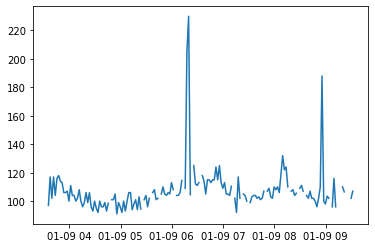

In [17]:
plt.plot(sample['ABPs'])

In [18]:
samples80 = [load_sample(sample_dict_control80[i]) for i in sample_dict_control80]
samples90 = [load_sample(sample_dict_control90[i]) for i in sample_dict_control90]
samples_vaso = {med: [
    load_sample(sample_dict_vaso[med][i])
    for i in sample_dict_vaso[med]
] for med in sample_dict_vaso }

In [46]:
for med in samples_vaso:
    print(med, len(samples_vaso[med]))

norepinephrine 2092
epinephrine 488
dobutamine 1410
Loop diuretics 5259
Benzodiacepine 3582
Propofol 1748
Opiate 4497


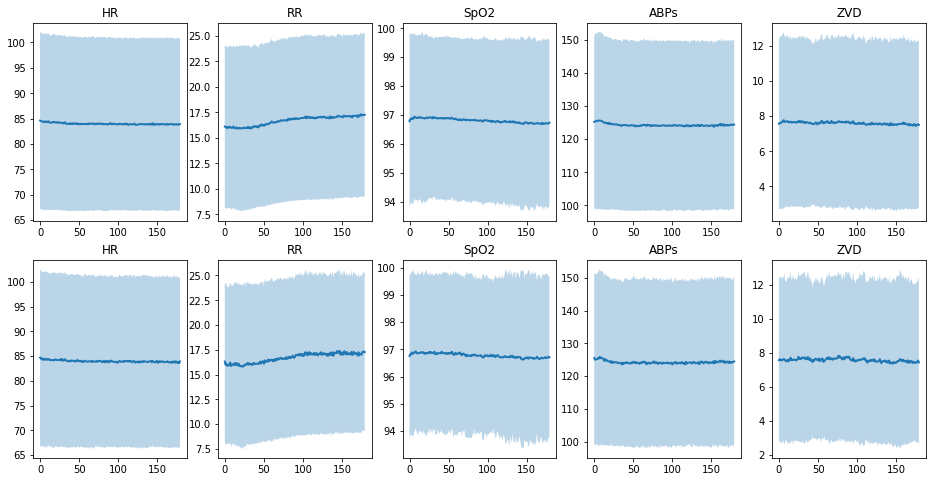

In [22]:
fig, ax = plt.subplots(2, 5, figsize=(16, 8))
physio_plot = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']

for i, dfs in enumerate([samples80, samples90]):
    for j, physio in enumerate(physio_plot):
        data = [df[physio].reset_index(drop=True) for df in dfs]
        data = pd.concat(data, axis=1)

        mean = data.mean(1)
        std = data.std(1)

        ax[i][j].plot(mean, linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean-std, 
                        mean+std, 
                        alpha=.3)
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{physio}')

In [35]:
dist_t_start80 = []
for i, df in enumerate(tqdm(samples80)):
    pid, _, _ = sample_dict_control80[i]
    info = patient_info[patient_info['patientid']==pid]
    dist_t_start80.append(patient_info.loc[patient_info['patientid']==pid, 'LOS'].item() - df['LOS'].iloc[0])
    
dist_t_start90 = []
for i, df in enumerate(tqdm(samples90)):
    pid, _, _ = sample_dict_control90[i]
    info = patient_info[patient_info['patientid']==pid]
    dist_t_start90.append(patient_info.loc[patient_info['patientid']==pid, 'LOS'].item() - df['LOS'].iloc[0])
    
dist_t_start_vaso = {med:[] for med in samples_vaso}
for med in samples_vaso:
    for i, df in enumerate(tqdm(samples_vaso[med])):
        pid, _, _ = sample_dict_vaso[med][i]
        info = patient_info[patient_info['patientid']==pid]
        dist_t_start_vaso[med].append(patient_info.loc[patient_info['patientid']==pid, 'LOS'].item() 
                                      - df['LOS'].iloc[0])

100%|█████████████████████████████████████████████████████████████████| 5182/5182 [00:03<00:00, 1521.11it/s]


(0.0, 200.0)

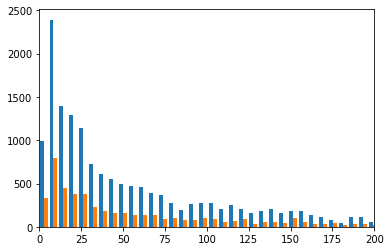

In [59]:
plt.hist([dist_t_start80, dist_t_start90], 
         bins=100, label=['control80', 'control90']);
plt.xlim(0, 200)

(0.0, 200.0)

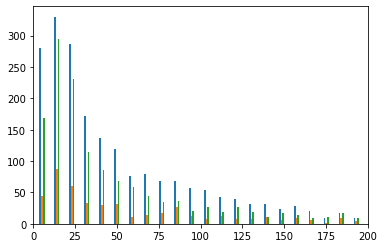

In [58]:
plt.hist([dist_t_start_vaso[med] for med in dist_t_start_vaso], 
         bins=100,
         label=['norepinephrine', 'epinephrine', 'dobutamine']);
plt.xlim(0, 200)

(0.0, 200.0)

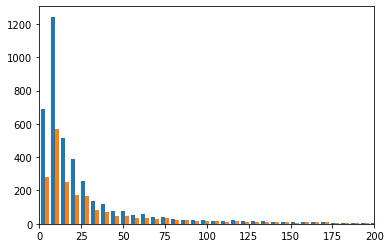

In [70]:
pid80 = [v[0] for k,v in sample_dict_control80.items()]
pid90 = [v[0] for k,v in sample_dict_control90.items()]
plt.hist([
    patient_info.loc[patient_info['patientid'].isin(pid80), 'LOS'],
    patient_info.loc[patient_info['patientid'].isin(pid90), 'LOS']
], bins=100)
plt.xlim(0, 200)

(0.0, 200.0)

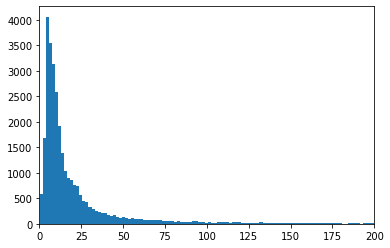

In [73]:
plt.hist(patient_info.loc[patient_info['patientid'].isin(pid_valid), 'LOS'], bins=500);
plt.xlim(0,200)

In [74]:
patient_info.loc[patient_info['patientid'].isin(pid_valid), 'LOS'].median()

10.559027777777777

In [86]:
patient_info.loc[patient_info['patientid'].isin(pid_valid), 'LOS'].quantile(.01)

1.361111111111111

# data version 3.0

add filter:
- patient stay >=1  ---  1% - 100%

In [1]:
import os
import pickle
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
from tqdm import tqdm
from tqdm.dask import TqdmCallback

import matplotlib.pyplot as plt

os.chdir('/home/kai/DigitalICU/Experiments/HIRID-PatientStateSpace/')
from utils.config_dataset import *
from utils.ClassDataset import MergedDataset
from utils.data_io import *

import warnings
warnings.filterwarnings("ignore")

RANDOMSEED=2024

save_path = 'processed-merge-v3/'

In [2]:
pid_valid = pickle.load(open(os.path.join(save_path, 'pid_valid.p'), 'rb'))
sample_dict_vaso = pickle.load(open(os.path.join(save_path, 'sample_lookuptable_per_med.p'), 'rb'))
sample_dict_control = pickle.load(open(os.path.join(save_path, 'sample_lookuptable_control_group.p'), 'rb'))

pid_sample_vaso = {med:[sample_dict_vaso[med][i][0] for i in sample_dict_vaso[med]] 
                   for med in sample_dict_vaso }
pid_sample_control = [sample_dict_control[i][0] for i in sample_dict_control]

In [3]:
for med in sample_dict_vaso:
    print(f"{med:<30} --- {len(sample_dict_vaso[med].keys())}")
    
pid_vaso_unique = pid_sample_vaso[MED_BENCHMARK[0]] \
                    + pid_sample_vaso[MED_BENCHMARK[1]] \
                    + pid_sample_vaso[MED_BENCHMARK[2]]
print('# Vaso sample pids: ', len(pid_vaso_unique) , '\n# Vaso sample unique pids: ', len(set(pid_vaso_unique)))

count = 0
for pid in set(pid_sample_control):
    if pid in pid_vaso_unique:
        count += 1
print('# PID in both control and vaso samples: ', count)

count = 0
for pid in pid_sample_control:
    if pid in set(pid_vaso_unique):
        count += 1
print('# control samples for the common PIDs: ', count)

norepinephrine                 --- 2092
epinephrine                    --- 488
dobutamine                     --- 1410
Loop diuretics                 --- 3445
Benzodiacepine                 --- 2008
Propofol                       --- 1214
Opiate                         --- 1882
# Vaso sample pids:  3990 
# Vaso sample unique pids:  3391
# PID in both control and vaso samples:  2993
# control samples for the common PIDs:  34098


In [4]:
pid_control, counts = np.unique(pid_sample_control, return_counts=True)
for pid, num in zip(pid_control, counts):
    print(f"{pid:<10} --- {num}")

4          --- 13
9          --- 2
18         --- 1
24         --- 2
27         --- 6
29         --- 1
30         --- 28
36         --- 5
40         --- 1
42         --- 2
46         --- 1
50         --- 1
52         --- 2
56         --- 9
66         --- 1
69         --- 16
71         --- 1
74         --- 1
83         --- 3
97         --- 10
99         --- 4
101        --- 1
104        --- 8
105        --- 4
109        --- 3
118        --- 2
123        --- 2
126        --- 4
128        --- 2
129        --- 10
132        --- 1
134        --- 1
136        --- 7
137        --- 3
141        --- 11
144        --- 4
151        --- 2
154        --- 2
160        --- 15
161        --- 7
167        --- 4
172        --- 27
175        --- 3
182        --- 5
183        --- 1
188        --- 30
194        --- 3
197        --- 8
199        --- 1
206        --- 3
209        --- 12
211        --- 1
217        --- 1
225        --- 12
227        --- 8
235        --- 22
237        --- 29
239        --- 2
2

7346       --- 1
7357       --- 25
7358       --- 3
7361       --- 3
7365       --- 15
7368       --- 8
7370       --- 20
7372       --- 2
7380       --- 4
7384       --- 31
7385       --- 8
7390       --- 1
7397       --- 4
7399       --- 5
7400       --- 3
7403       --- 1
7405       --- 4
7407       --- 6
7408       --- 9
7416       --- 12
7417       --- 1
7418       --- 1
7419       --- 14
7420       --- 11
7421       --- 4
7424       --- 2
7426       --- 5
7430       --- 2
7435       --- 1
7442       --- 7
7444       --- 2
7447       --- 1
7450       --- 19
7462       --- 2
7468       --- 2
7469       --- 6
7473       --- 2
7477       --- 32
7480       --- 1
7487       --- 2
7491       --- 6
7493       --- 20
7496       --- 1
7497       --- 2
7500       --- 4
7501       --- 2
7508       --- 1
7510       --- 1
7513       --- 9
7517       --- 1
7523       --- 4
7529       --- 7
7530       --- 2
7534       --- 39
7542       --- 1
7543       --- 20
7544       --- 30
7547       --- 37


18743      --- 1
18745      --- 4
18750      --- 2
18756      --- 1
18757      --- 15
18758      --- 2
18759      --- 2
18762      --- 2
18764      --- 1
18765      --- 6
18767      --- 1
18769      --- 2
18781      --- 1
18783      --- 2
18787      --- 1
18794      --- 26
18795      --- 5
18796      --- 5
18799      --- 22
18803      --- 11
18809      --- 15
18812      --- 2
18817      --- 21
18818      --- 7
18825      --- 1
18826      --- 21
18827      --- 2
18828      --- 11
18846      --- 10
18851      --- 4
18853      --- 9
18855      --- 1
18865      --- 80
18870      --- 20
18871      --- 3
18872      --- 2
18874      --- 1
18881      --- 1
18886      --- 2
18892      --- 3
18899      --- 1
18903      --- 2
18908      --- 4
18910      --- 7
18922      --- 6
18923      --- 1
18924      --- 2
18929      --- 3
18935      --- 2
18938      --- 4
18940      --- 1
18942      --- 1
18943      --- 1
18948      --- 4
18950      --- 2
18953      --- 4
18958      --- 24
18963      --- 1
18

20735      --- 2
20741      --- 3
20743      --- 2
20759      --- 2
20761      --- 5
20765      --- 1
20767      --- 7
20771      --- 2
20784      --- 13
20785      --- 4
20791      --- 31
20792      --- 14
20797      --- 2
20800      --- 10
20801      --- 1
20809      --- 37
20814      --- 15
20819      --- 1
20822      --- 2
20826      --- 20
20833      --- 1
20834      --- 1
20837      --- 1
20840      --- 6
20843      --- 3
20845      --- 1
20848      --- 2
20854      --- 2
20860      --- 1
20868      --- 1
20879      --- 5
20880      --- 23
20883      --- 2
20886      --- 7
20887      --- 1
20891      --- 2
20895      --- 3
20899      --- 1
20901      --- 1
20902      --- 8
20909      --- 2
20910      --- 7
20913      --- 1
20919      --- 1
20920      --- 43
20922      --- 2
20926      --- 2
20934      --- 1
20935      --- 7
20936      --- 4
20938      --- 2
20944      --- 88
20947      --- 2
20949      --- 2
20954      --- 67
20971      --- 7
20976      --- 5
20978      --- 1
209

33496      --- 3
33498      --- 1
33501      --- 1
33503      --- 38
33515      --- 13
33516      --- 8
33519      --- 12
33522      --- 1
33527      --- 18
33530      --- 1
33532      --- 1
33539      --- 5
33543      --- 2
33564      --- 2
33565      --- 3
33569      --- 24
33571      --- 2
33574      --- 3
33575      --- 1
33579      --- 15
33582      --- 2
33583      --- 4
33586      --- 20
33601      --- 16
33618      --- 1
33619      --- 3
33624      --- 5
33625      --- 35
33627      --- 21
33628      --- 4
33629      --- 2
33632      --- 5
33637      --- 1
33639      --- 1
33644      --- 4
33651      --- 1
33657      --- 2
33658      --- 53
33660      --- 16
33661      --- 14
33663      --- 1
33670      --- 3
33677      --- 15
33679      --- 8
33690      --- 73
33710      --- 1
33723      --- 4
33724      --- 1
33726      --- 2
33730      --- 1
33731      --- 10
33737      --- 51
33740      --- 2
33741      --- 2
33744      --- 3
33747      --- 3
33752      --- 6
33755      ---

In [5]:
len(pid_sample_control), len(set(pid_sample_control))

(65198, 8031)

In [6]:
patient_info = pickle_load(os.path.join(save_path, 'patient_info.p'))
sample_dict_vaso60 = pickle_load(os.path.join(save_path, 'sample_dict_vasopressor_filtered60.p'))
sample_dict_vaso70 = pickle_load(os.path.join(save_path, 'sample_dict_vasopressor_filtered70.p'))
sample_dict_vaso80 = pickle_load(os.path.join(save_path, 'sample_dict_vasopressor_filtered80.p'))
sample_dict_control80 = pickle_load(os.path.join(save_path, 'sample_dict_control_filtered80.p'))
sample_dict_control90 = pickle_load(os.path.join(save_path, 'sample_dict_control_filtered90.p'))

In [7]:
for miss_rate, sample_dict in zip([60, 70, 80], [sample_dict_vaso60, sample_dict_vaso70, sample_dict_vaso80]):
    count = {med: 0 for med in MED_BENCHMARK[:3]}
    for k in sample_dict:
        count[sample_dict[k][0]] += 1
    print(f"Missing rate --- {miss_rate}%")    
    for med in count:
        print(f"{med:<20} --- {count[med]}")

Missing rate --- 60%
norepinephrine       --- 1953
epinephrine          --- 471
dobutamine           --- 1392
Missing rate --- 70%
norepinephrine       --- 1694
epinephrine          --- 433
dobutamine           --- 1354
Missing rate --- 80%
norepinephrine       --- 1204
epinephrine          --- 352
dobutamine           --- 1192


In [17]:
samples_vaso_80 = {med: [] for med in MED_BENCHMARK[:3] }
for i in tqdm(sample_dict_vaso80):
    med,_,_,_ = sample_dict_vaso80[i]
    samples_vaso_80[med] += [load_sample(save_path, sample_dict_vaso80[i])]
    
samples_control_80 = [load_sample(save_path, sample_dict_control80[i]) for i in tqdm(sample_dict_control80)]

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 2748/2748 [00:08<00:00, 306.97it/s]


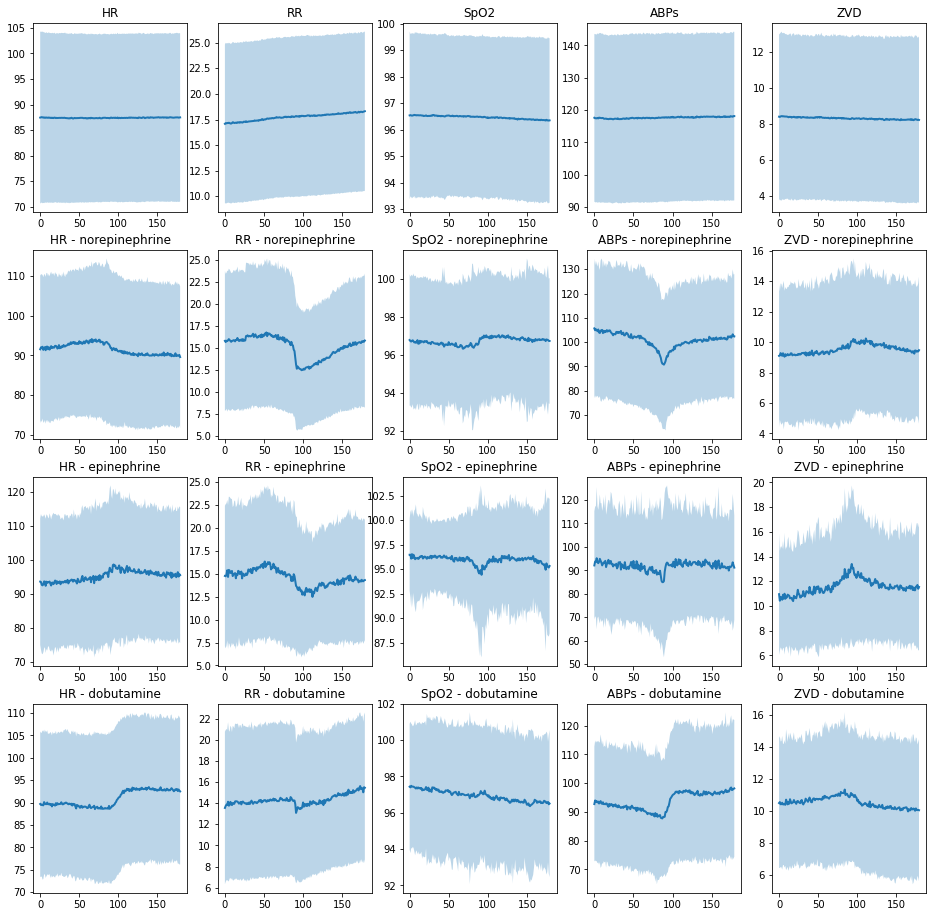

In [18]:
fig, ax = plt.subplots(4, 5, figsize=(16, 16))
physio_plot = ['HR', 'RR', 'SpO2', 'ABPs', 'ZVD']

for i, med in enumerate(MED_BENCHMARK[:3]):
    dfs = samples_vaso_80[med]
    for j, physio in enumerate(physio_plot):
        data = [df[physio].reset_index(drop=True) for df in dfs]
        data = pd.concat(data, axis=1)

        mean = data.mean(1)
        std = data.std(1)

        ax[i+1][j].plot(mean, linewidth=2);
        ax[i+1][j].fill_between(range(180), 
                        mean-std, 
                        mean+std, 
                        alpha=.3)
    #     ax.set_ylim(0.2, 0.4)
        ax[i+1][j].set_title(f'{physio} - {med}')

for i, dfs in enumerate([samples_control_80]):
    for j, physio in enumerate(physio_plot):
        data = [df[physio].reset_index(drop=True) for df in dfs]
        data = pd.concat(data, axis=1)

        mean = data.mean(1)
        std = data.std(1)

        ax[i][j].plot(mean, linewidth=2);
        ax[i][j].fill_between(range(180), 
                        mean-std, 
                        mean+std, 
                        alpha=.3)
    #     ax.set_ylim(0.2, 0.4)
        ax[i][j].set_title(f'{physio}')
        


100%|███████████████████████████████████████████████████████████████████████████████████████████| 32098/32098 [00:20<00:00, 1603.18it/s]


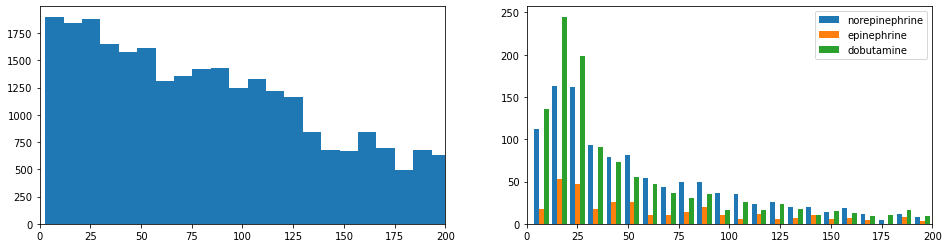

In [23]:
dist_t_start_vaso = {med:[] for med in samples_vaso_80}
sample_dict_vaso80_ = {med: {} for med in samples_vaso_80}
for i in sample_dict_vaso80:
    med, pid, t_start, t_end = sample_dict_vaso80[i]
    i_new = len(sample_dict_vaso80_[med])
    sample_dict_vaso80_[med][i_new] = (pid, t_start, t_end)
    
for med in samples_vaso_80:
    for i, df in enumerate(tqdm(samples_vaso_80[med])):
        pid, _, _ = sample_dict_vaso80_[med][i]
        info = patient_info[patient_info['patientid']==pid]
        dist_t_start_vaso[med].append(patient_info.loc[patient_info['patientid']==pid, 'LOS'].item() 
                                      - df['LOS'].iloc[0])

dist_t_start80 = []
for i, df in enumerate(tqdm(samples_control_80)):
    pid, _, _ = sample_dict_control80[i]
    info = patient_info[patient_info['patientid']==pid]
    dist_t_start80.append(patient_info.loc[patient_info['patientid']==pid, 'LOS'].item() - df['LOS'].iloc[0])
        

fig, ax = plt.subplots(1,2, figsize=(16, 4))
ax[0].hist(dist_t_start80, bins=100, label=['control'])
ax[0].set_xlim(0, 200)
ax[1].hist([dist_t_start_vaso[med] for med in dist_t_start_vaso], 
           bins=100,
           label=['norepinephrine', 'epinephrine', 'dobutamine']
          );
ax[1].set_xlim(0, 200)
plt.legend()